# 4 — Décrire ou modéliser

**Où en est-on.** Les trois notebooks précédents ont chacun montré qu'une
réponse apparemment solide reposait sur un choix invisible :

| | Le choix invisible | Ce qu'il changeait |
|---|---|---|
| `02` | la **population** de scrutins retenue | l'accord LFI↔SOC passe de 79 % à 63 % |
| `03` | la **relation** que l'on mesure | LFI et ECOS votent à 88 % et ne cosignent presque jamais |
| `04` | la **méthode** elle-même | ce qu'on a le droit d'affirmer |
| `05` | les **données écartées** | l'abstention décide, parfois |

Ce notebook s'attaque au troisième — et laisse au `05` le soin de démentir une
de ses propres affirmations. Il ne s'agit pas de remplacer l'analyse en
composantes principales du notebook `01` — elle reste le bon outil pour une
première carte — mais de comprendre **ce qu'elle ne peut pas dire**, et ce qu'un
modèle permet d'affirmer en plus.

**Ce qu'on établit au passage :** l'Assemblée ne tient pas sur un seul axe. Il y
a deux oppositions systématiques, celle de LFI et celle du RN, et elles ne
portent pas sur les mêmes textes — ce qui interdit de les ranger sur une même
ligne.

In [1]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

from radar import analyze, ideal, viz

viz.set_theme("clair")
pl.Config.set_tbl_rows(20)
pl.Config.set_fmt_str_lengths(70)

# On travaille sur les votes qui engagent — la leçon du notebook 02.
cube = analyze.build_cube(portee="texte")
print(f"{cube.n_deputes} députés × {cube.n_scrutins} votes sur l'ensemble d'un texte")

577 députés × 245 votes sur l'ensemble d'un texte


## 1. Ce que l'ACP fait, et ce qu'elle ne fait pas

L'ACP du notebook `01` prend la matrice des votes (+1 pour, −1 contre) et
cherche les directions de plus grande variance. C'est une méthode
**descriptive** : elle ne suppose rien, ne s'ajuste pas, ne se règle pas. Elle
place correctement les députés et produit une carte lisible en une fraction de
seconde.

Ses limites tiennent à ce qu'elle ne modélise rien :

- elle traite un vote comme un nombre continu alors qu'il vaut « pour » ou
  « contre » — il n'y a pas de vote « 0,3 » ;
- elle renvoie un point par député, sans marge d'erreur, alors qu'une position
  estimée sur 245 votes est nécessairement approximative ;
- elle ne dit rien des **scrutins** : impossible de savoir lequel a activé le
  clivage principal et lequel l'a traversé ;
- ses pourcentages de variance décrivent l'échantillon, mais ne se testent pas.

## 2. Le modèle, en une phrase et une image

Le modèle de Clinton, Jackman et Rivers (2004) suppose que le vote naît d'une
comparaison de positions :

$$P(\text{le député } i \text{ vote « pour » au scrutin } j) = \text{logistique}(\beta_j \, x_i - \alpha_j)$$

Trois quantités, et trois seulement :

- $x_i$ — le **point idéal** du député. C'est l'inconnue principale : sa
  position sur l'axe que les votes révèlent.
- $\beta_j$ — la **discrimination** du scrutin. À quel point ce vote sépare
  l'Assemblée selon cet axe.
- $\alpha_j$ — la **difficulté**. Où se situe le point de bascule.

L'image à retenir : rangez les députés sur une ligne. Un scrutin trace une
**frontière** sur cette ligne — d'un côté on vote contre, de l'autre pour. Alors
$\alpha_j / \beta_j$ dit **où** passe la frontière, et $\beta_j$ dit **à quel
point elle est nette**. Estimer le modèle, c'est chercher le rangement des
députés qui rend le plus grand nombre de scrutins explicables par une frontière.

## 3. Le graphique qui explique tout

Une courbe caractéristique met le modèle à nu. En abscisse la position estimée
des députés, en ordonnée la probabilité de voter « pour ». La courbe est le
modèle, les points gris sont les votes réellement exprimés.

In [2]:
modele = ideal.estimer(cube, dimensions=1)
print(f"{modele.n_votes:,} votes utilisés · classification {modele.classification:.1%} "
      f"· APRE {modele.apre:.3f}")

force = np.abs(modele.discrimination[:, 0])
scrutin_net = int(np.argmax(force))
scrutin_flou = int(np.argmin(force))

35,008 votes utilisés · classification 94.6% · APRE 0.826


findfont: Failed to find font weight semibold, now using 700.


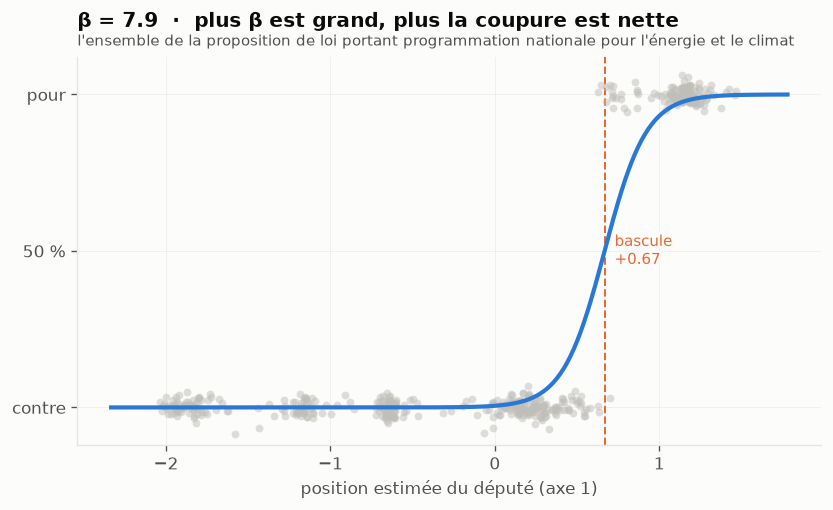

In [3]:
viz.courbe_scrutin(modele, scrutin_net)
plt.show()

Une marche d'escalier : la position d'un député suffit à prédire son vote. La
frontière est nette, les votes réels se rangent proprement de part et d'autre.
C'est un scrutin qui a activé le clivage principal.

Le même graphique pour un scrutin que l'axe n'explique pas :

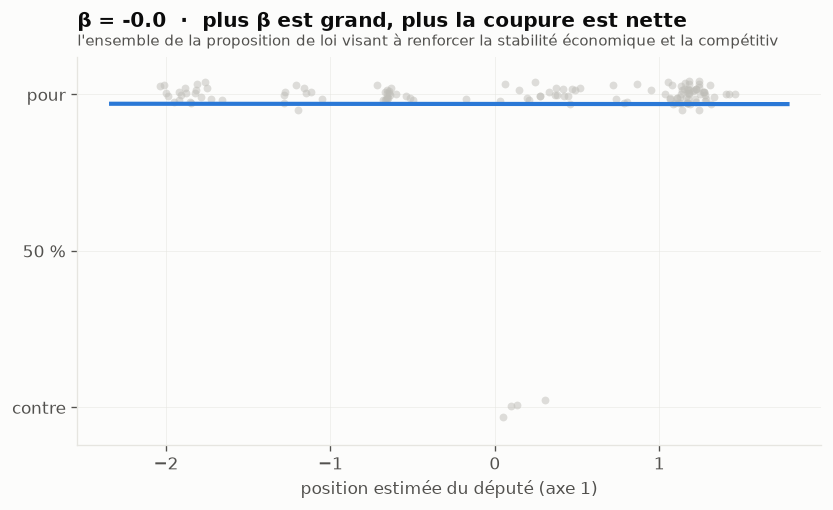

In [4]:
viz.courbe_scrutin(modele, scrutin_flou)
plt.show()

Courbe presque plate, votes mélangés : connaître la position d'un député
n'apprend rien sur son vote. Ce scrutin a traversé les camps.

**Cette distinction n'existe pas dans l'ACP.** Elle est pourtant le cœur du
sujet : elle dit quels votes structurent l'Assemblée et lesquels la
recomposent.

## 4. Comment le modèle s'estime — et le piège qu'on y rencontre

L'estimation alterne deux étapes : à positions fixées on ajuste les paramètres
de chaque scrutin ; à paramètres fixés on ajuste les positions. On répète
jusqu'à stabilisation.

Le piège est la **séparation quasi parfaite**. Sur des votes d'ensemble,
beaucoup de scrutins opposent des blocs sans la moindre exception. Le maximum de
vraisemblance part alors à l'infini : $\beta$ explose, la courbe devient
verticale, et — c'est le symptôme visible — les positions se tassent les unes
sur les autres, puisqu'un écart minuscule suffit à tout expliquer.

La parade est de pénaliser $\beta$. Mais de combien ? Pas à l'œil : plus la
pénalisation est faible, meilleur est l'ajustement **en échantillon**. Le seul
juge honnête est la prédiction de votes non vus.

In [5]:
reglage = ideal.choisir_penalisation(cube, n_repetitions=3)
reglage

ridge_discrimination,apre_apprentissage,apre_test,beta_max
f64,f64,f64,f64
0.02,0.841922,0.814337,24.46607
0.1,0.836964,0.812131,12.204211
0.5,0.836692,0.813861,7.48331
2.0,0.827066,0.802631,4.838004
8.0,0.806376,0.777046,2.885764


La colonne `apre_test` culmine autour de 0,5, et `beta_max` montre l'enjeu
concret : à pénalisation faible, les discriminations atteignent plusieurs
dizaines — des courbes verticales et une estimation fragile. C'est la valeur
retenue par défaut.

## 5. Le résultat, et sa comparaison avec l'ACP

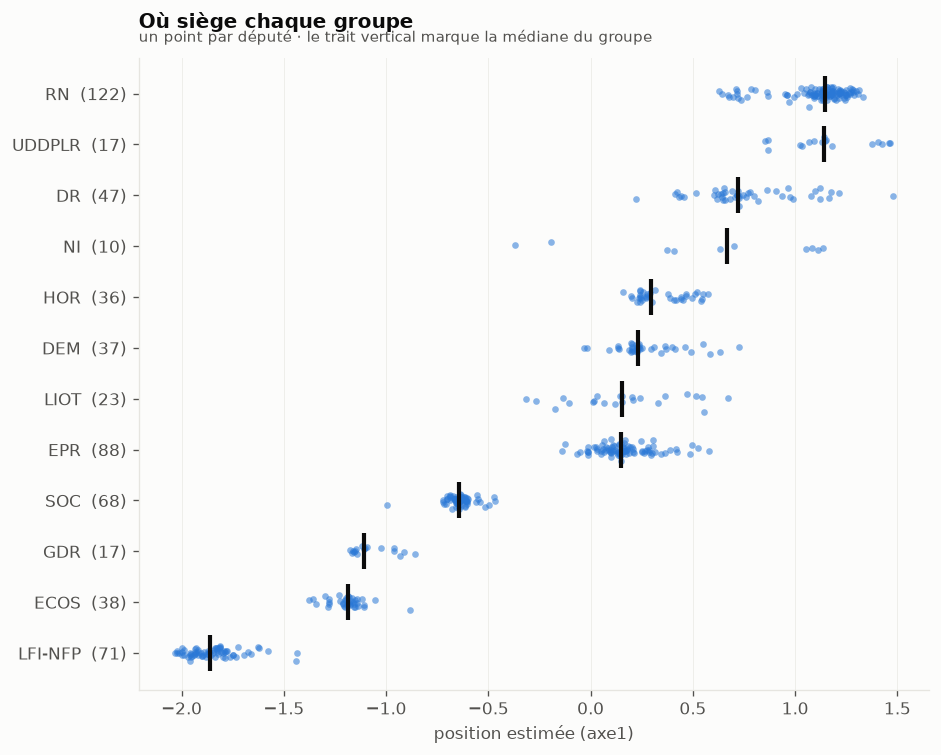

In [6]:
positions = modele.table_deputes()
viz.positions_par_groupe(positions)
plt.show()

L'ordre est monotone et sans surprise : LFI-NFP, ECOS, GDR, SOC, puis le bloc
central, puis DR, UDDPLR et RN. La dispersion interne se lit directement — les
non-inscrits sont étalés, ce qui est attendu d'un non-groupe.

Le modèle et l'ACP racontent-ils la même chose ? Vérifions plutôt que de le
supposer.

In [7]:
acp = analyze.carte_politique(cube, methode="pca")
comparaison = (
    positions.join(
        acp.select("nom_complet", pl.col("x").alias("acp_axe1")),
        on="nom_complet", how="inner",
    )
)
r = np.corrcoef(comparaison["axe1"], comparaison["acp_axe1"])[0, 1]
print(f"corrélation entre le point idéal et le premier axe de l'ACP : {r:+.3f}")

corrélation entre le point idéal et le premier axe de l'ACP : +0.952


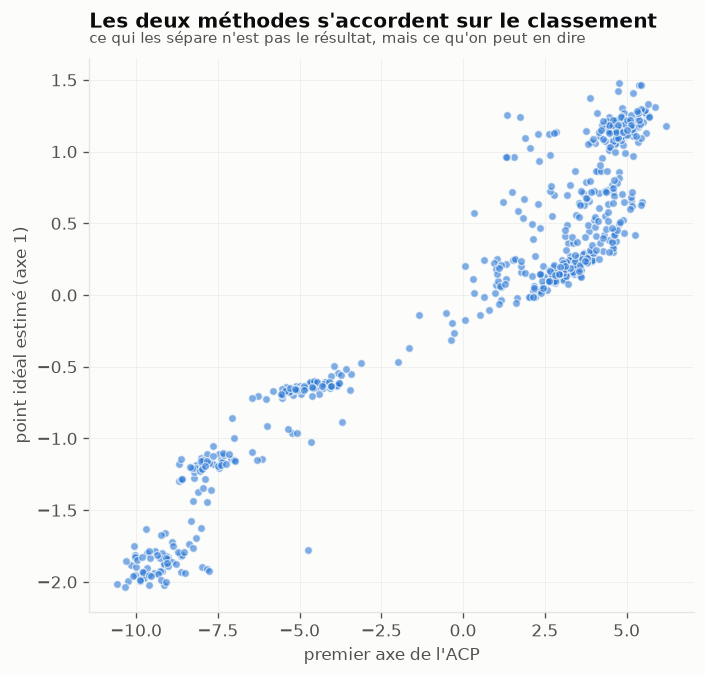

In [8]:
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(comparaison["acp_axe1"], comparaison["axe1"], s=22,
           c=viz._theme.accent, alpha=0.6, edgecolors=viz._theme.surface, linewidths=0.8)
ax.set_xlabel("premier axe de l'ACP")
ax.set_ylabel("point idéal estimé (axe 1)")
ax.grid(lw=0.6, alpha=0.5)
ax.set_axisbelow(True)
viz._habiller(ax, "Les deux méthodes s'accordent sur le classement",
              "ce qui les sépare n'est pas le résultat, mais ce qu'on peut en dire")
plt.show()

Les deux méthodes classent les députés presque identiquement. **C'est le
résultat qu'on espérait** : si elles divergeaient, l'une des deux serait
suspecte. L'ACP n'est donc pas « fausse », et il n'y a aucune raison de la
retirer du notebook `01`.

Ce qui suit est ce que le modèle ajoute, et que l'ACP ne pouvait pas fournir.

## 6. Premier apport : une position est une zone, pas un point

On rééchantillonne les scrutins avec remise, on réestime, et on regarde à quel
point la position d'un député bouge.

In [9]:
avec_marges = ideal.intervalles(cube, n_bootstrap=60)
print(f"largeur médiane de l'intervalle à 90 % : {avec_marges['largeur'].median():.2f}")
print(f"étendue totale de l'axe : {avec_marges['axe1'].max() - avec_marges['axe1'].min():.2f}")

largeur médiane de l'intervalle à 90 % : 0.33
étendue totale de l'axe : 3.51


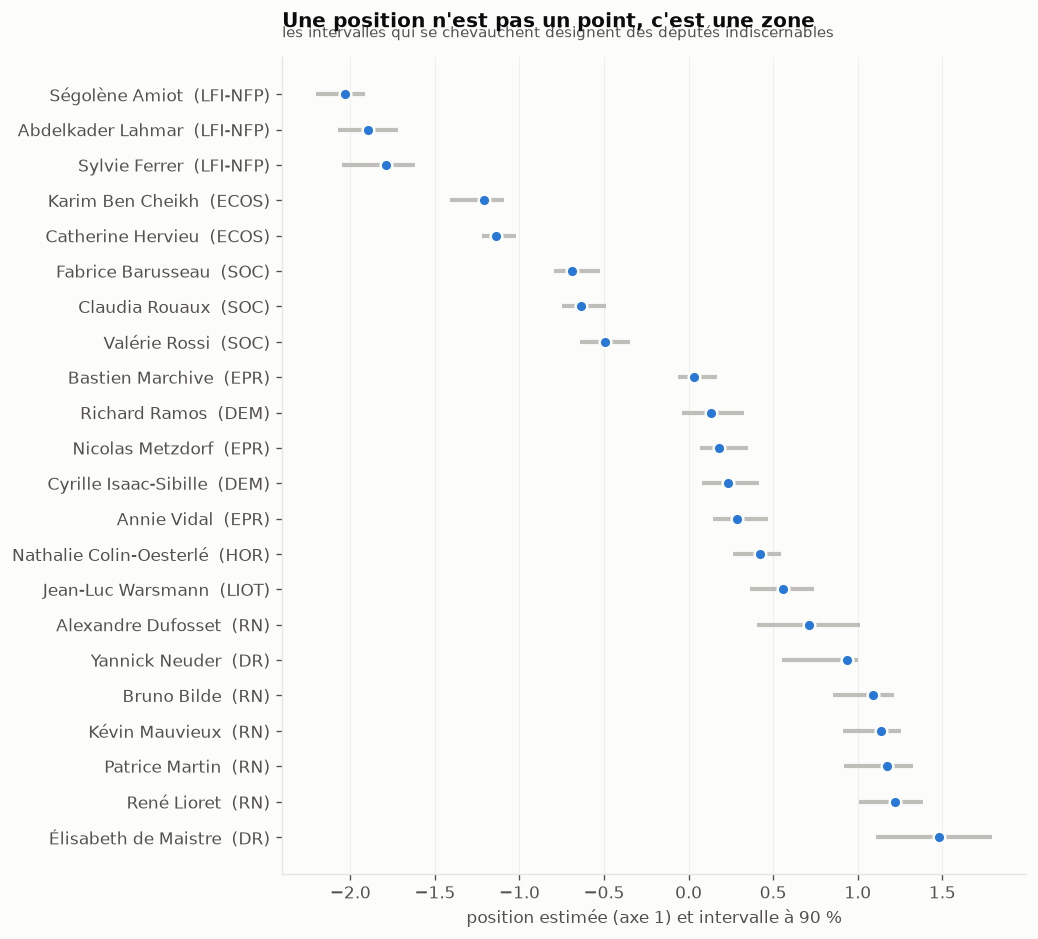

In [10]:
viz.intervalles_deputes(avec_marges, k=22)
plt.show()

L'intervalle médian fait environ un dixième de l'étendue de l'axe. Autrement
dit : un classement des députés un par un serait largement du bruit sur ses
positions voisines, alors que l'écart entre blocs, lui, est solide.

Sans ces barres, rien n'empêchait de titrer « le député le plus à gauche de
l'Assemblée » sur une différence de troisième décimale.

## 7. Deuxième apport : la lecture des scrutins

Le modèle attribue à chaque vote une force de séparation. On peut donc trier les
scrutins selon qu'ils ont activé le clivage principal ou l'ont traversé.

In [11]:
ideal.scrutins_discriminants(modele, k=6).select("date", "pouvoir_separateur", "titre")

date,pouvoir_separateur,titre
str,f64,str
"""2025-06-24""",7.852264,"""l'ensemble de la proposition de loi portant programmation nationale po…"
"""2026-07-15""",7.517769,"""l'ensemble du projet de loi visant à offrir des réponses immédiates au…"
"""2026-04-07""",7.429244,"""l'ensemble du projet de loi relatif à la lutte contre les fraudes soci…"
"""2026-05-19""",7.379247,"""l'ensemble du projet de loi actualisant la programmation militaire pou…"
"""2026-06-16""",7.373353,"""l'ensemble de la proposition de loi visant à renforcer la sécurité, la…"
"""2026-07-07""",7.352633,"""l'ensemble du projet de loi sur la justice criminelle et le respect de…"


In [12]:
ideal.scrutins_transversaux(modele, k=6).select("date", "pouvoir_separateur", "titre")

date,pouvoir_separateur,titre
str,f64,str
"""2025-03-17""",0.008967,"""l'ensemble de la proposition de loi visant à renforcer la stabilité éc…"
"""2025-12-09""",0.010956,"""l'ensemble du projet de loi de financement de la sécurité sociale pour…"
"""2025-12-16""",0.023703,"""l'ensemble du projet de loi de financement de la sécurité sociale pour…"
"""2025-04-09""",0.078499,"""l’ensemble de la proposition de loi visant à renforcer la stabilité éc…"
"""2025-05-15""",0.146024,"""l'ensemble de la proposition de loi visant à lutter contre la mortalit…"
"""2025-11-18""",0.178981,"""l'ensemble du projet de loi de finances de fin de gestion pour 2025 (p…"


Les seconds sont les plus intéressants journalistiquement : ce sont les textes
qui recomposent l'hémicycle au lieu de le confirmer.

## 8. Troisième apport : combien de dimensions ?

L'ACP donne des pourcentages de variance, qu'on ne peut pas tester. Le modèle
permet de poser la question autrement : une dimension de plus aide-t-elle à
prédire **des votes qu'elle n'a pas vus** ?

Le piège est ici particulièrement traître. Ajouter une dimension ajoute 577
paramètres, et l'ajustement en échantillon ne peut que s'améliorer. Mesuré
ainsi, le modèle à deux dimensions classe 95 % des votes — un chiffre qui ne dit
rien d'autre que « il y a assez de paramètres pour mémoriser ».

In [13]:
dims = ideal.evaluer_dimensionnalite(cube, max_dimensions=3, n_repetitions=3)
dims.select("dimensions", "n_parametres", "apre_apprentissage", "apre_test",
            "surajustement", "gain_hors_echantillon")

dimensions,n_parametres,apre_apprentissage,apre_test,surajustement,gain_hors_echantillon
i64,i64,f64,f64,f64,f64
1,828,0.836692,0.813861,0.022831,null
2,1529,0.953746,0.923842,0.029904,0.109981
3,2230,0.979084,0.943713,0.035371,0.019871


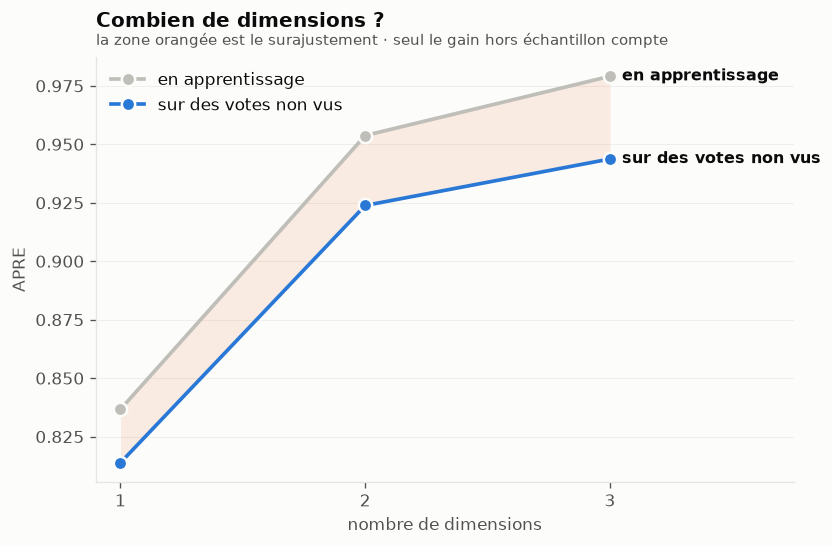

In [14]:
viz.dimensionnalite(dims)
plt.show()

Le second axe apporte un gain net **hors échantillon** ; le troisième n'apporte
presque plus rien tout en creusant l'écart entre apprentissage et test. La
conclusion est nette : **deux dimensions se justifient, trois non.**

## 9. Que sépare ce second axe ?

In [15]:
modele2 = ideal.estimer(cube, dimensions=2)
(modele2.table_deputes()
        .group_by("groupe")
        .agg(pl.col("axe1").median().round(2),
             pl.col("axe2").median().round(2),
             pl.len())
        .sort("axe2"))

groupe,axe1,axe2,len
str,f64,f64,u32
"""SOC""",-0.31,-1.43,68
"""ECOS""",-1.29,-0.98,38
"""EPR""",0.98,-0.9,88
"""HOR""",0.87,-0.45,36
"""DEM""",0.86,-0.4,37
"""GDR""",-1.18,-0.31,17
"""LIOT""",0.42,-0.25,23
"""LFI-NFP""",-1.94,0.21,71
"""NI""",0.55,0.29,10


Voilà l'explication. En deux dimensions, l'axe 1 oppose **LFI au reste de
l'Assemblée**, et l'axe 2 oppose **le RN et UDDPLR au reste**.

Ce sont deux oppositions systématiques distinctes, et elles ne portent pas sur
les mêmes textes : LFI et RN votent tous deux beaucoup contre, mais rarement
contre les mêmes choses. Impossible de les ranger sur une seule ligne — d'où le
gain massif de la seconde dimension, et d'où la forme en fer à cheval qu'on
observait déjà sur la carte du notebook `01` sans pouvoir l'expliquer.

Un chiffre confirme cette lecture, sans aucun modèle : sur les votes
d'ensemble, LFI ne vote « pour » que dans la moitié des cas, quand le bloc
gouvernemental dépasse 90 %.

In [16]:
groupes = np.array(cube.groupes())
lignes = []
for g in sorted({x for x in groupes if x}):
    sel = groupes == g
    pour = int(cube.pour[sel].sum())
    contre = int(cube.contre[sel].sum())
    lignes.append({"groupe": g, "part_pour": pour / (pour + contre),
                   "votes_exprimes": pour + contre})
pl.DataFrame(lignes).sort("part_pour")

groupe,part_pour,votes_exprimes
str,f64,i64
"""LFI-NFP""",0.520336,8212
"""GDR""",0.594046,1478
"""ECOS""",0.623188,4140
"""SOC""",0.738146,6580
"""RN""",0.859622,12908
"""UDDPLR""",0.864331,1570
"""NI""",0.874251,668
"""DR""",0.909923,3386
"""LIOT""",0.91352,1642


## 10. Les députés pivots

Sur un vote serré, ce sont les députés proches de la médiane qui font basculer
le résultat. Le modèle les désigne directement.

In [17]:
ideal.pivots(modele, k=15).select("nom_complet", "groupe", "axe1", "distance_mediane")

nom_complet,groupe,axe1,distance_mediane
str,str,f64,f64
"""Jean Terlier""","""EPR""",0.204804,0.000137
"""Bruno Fuchs""","""DEM""",0.204531,0.000137
"""Caroline Yadan""","""EPR""",0.20514,0.000473
"""Sandrine Josso""","""DEM""",0.203984,0.000683
"""Marie Lebec""","""EPR""",0.206675,0.002007
"""Jean-Paul Mattei""","""DEM""",0.202291,0.002377
"""Stéphane Viry""","""LIOT""",0.207332,0.002665
"""Olivier Serva""","""LIOT""",0.200847,0.00382
"""Christine Le Nabour""","""HOR""",0.200381,0.004286


## 11. Alors, ACP ou modèle ?

Les deux, pour des usages différents :

| | ACP (`analyze.carte_politique`) | Points idéaux (`ideal.estimer`) |
|---|---|---|
| **Question** | qui est près de qui ? | comment un vote se produit-il ? |
| **Coût** | instantané, aucun réglage | quelques secondes, une pénalisation à choisir |
| **Robustesse** | très élevée, rien à casser | dépend du réglage et de la convergence |
| **Incertitude** | non | oui, par bootstrap |
| **Lecture des scrutins** | non | oui, β et point de bascule |
| **Test de dimensionnalité** | non | oui, hors échantillon |
| **Bon pour** | une carte, un premier aperçu, un public large | une affirmation qu'il faudra défendre |

En pratique : l'ACP pour publier une carte, le modèle dès qu'on veut écrire
« ce député est plus à gauche que celui-là » ou « ce vote a recomposé
l'hémicycle ».

## 12. Limites

- **Les abstentions sont exclues, et c'est la limite la plus coûteuse.** Le
  modèle logistique est binaire par construction : il n'a pas de troisième
  issue à prédire. On a d'abord justifié cette exclusion en avançant qu'une
  abstention n'était pas une position intermédiaire — le notebook `05` teste
  cette affirmation et **la dément dans 71 % des scrutins**. La bonne
  formulation est donc : le modèle ne sait pas représenter l'abstention, alors
  qu'elle porte de l'information. Un modèle ordonné (pour / abstention /
  contre) serait le bon outil.
- **Les positions sont supposées fixes** sur toute la période. Un député qui
  évolue apparaît à une position moyenne qui ne correspond à aucun moment
  réel. Une estimation par fenêtre glissante répondrait à cette objection.
- **Le modèle est ajusté sur 245 votes d'ensemble.** Les résultats ne se
  transposent pas aux votes d'amendement, qui obéissent à une autre logique —
  c'est précisément la leçon du notebook `02`.
- **La pénalisation est un choix**, réglé par validation croisée mais qui
  reste un choix. La section 4 montre sa sensibilité.

En ligne de commande :

```bash
uv run radar positions --incertitude
uv run radar positions --pivots
uv run radar dimensions
```